In [1]:
import numpy as np 
import scipy 
import matplotlib.pyplot as plt
from data import *
from optimization import *
import torch
rng = np.random.default_rng(seed=0)

In [5]:
# well-posed params 
c1, lambda1, lambda2 = torch.Tensor([0.4]), torch.Tensor([0.005]), torch.Tensor([0.01])
t = torch.linspace(0.0, 100, 32)
clean_signal, noisy_signal = make_synthetic_observation_three_param(c1, lambda1, lambda2, t, 0.05, rng=rng)
print(f'{torch.sum(clean_signal - noisy_signal):.4f}')

0.1660


In [6]:
# now recover: compile over many inits 
solutions = []
clean_signals = []
from tqdm import tqdm
for _ in tqdm(range(100), desc='Running Direct NLLS with different inits'):
    x_init = rng.random(3)
    clean_signal, noisy_signal = make_synthetic_observation_three_param(c1, lambda1, lambda2, t, 0.05)
    print(f'Initial guess: {x_init}, clean-noisy sum: {torch.sum(clean_signal - noisy_signal):.4f}')
    result = solve_direct_nlls(noisy_signal, t, x_init=x_init)
    solutions.append(result['x_hat'])
    clean_signal_recovered, _ = make_synthetic_observation_three_param(result['x_hat'][0], result['x_hat'][1], result['x_hat'][2], t, 0.0)
    clean_signals.append(clean_signal_recovered)

Running Direct NLLS with different inits:  27%|██▋       | 27/100 [00:00<00:00, 262.34it/s]

Initial guess: [0.5540905  0.80971078 0.56047595], clean-noisy sum: 0.7632
Initial guess: [0.28842121 0.41289634 0.81812097], clean-noisy sum: 0.0181
Initial guess: [0.62650646 0.95907764 0.36940441], clean-noisy sum: 0.3384
Initial guess: [0.55261151 0.5939242  0.84829121], clean-noisy sum: -0.0062
Initial guess: [0.14547354 0.40651034 0.90995896], clean-noisy sum: 0.2278
Initial guess: [0.04306689 0.82270628 0.41538404], clean-noisy sum: -0.2754
Initial guess: [0.82980399 0.00995456 0.36504616], clean-noisy sum: 0.2015
Initial guess: [0.07863004 0.65261458 0.2738491 ], clean-noisy sum: 0.1043
Initial guess: [0.70265207 0.94380143 0.1268171 ], clean-noisy sum: 0.3551
Initial guess: [0.8647783  0.05946415 0.38077051], clean-noisy sum: -0.1430
Initial guess: [0.42977406 0.48884955 0.97646232], clean-noisy sum: -0.2305
Initial guess: [0.77569119 0.30885736 0.26983679], clean-noisy sum: 0.3277
Initial guess: [0.8631202  0.88130717 0.51070651], clean-noisy sum: 0.0132
Initial guess: [0.344

Running Direct NLLS with different inits: 100%|██████████| 100/100 [00:00<00:00, 249.92it/s]

Initial guess: [0.75344654 0.91383767 0.47614707], clean-noisy sum: -0.0748
Initial guess: [0.86378624 0.70156857 0.29392426], clean-noisy sum: 0.2797
Initial guess: [0.76765227 0.57068479 0.09384515], clean-noisy sum: 0.2268
Initial guess: [0.39138043 0.07374101 0.47616696], clean-noisy sum: 0.6198
Initial guess: [0.42853961 0.42373744 0.58630035], clean-noisy sum: -0.1201
Initial guess: [0.12269066 0.93376891 0.68405045], clean-noisy sum: 0.1152
Initial guess: [0.82378136 0.89680123 0.58332005], clean-noisy sum: 0.2465
Initial guess: [0.04021822 0.71148682 0.56902585], clean-noisy sum: 0.0358
Initial guess: [0.82595722 0.53216047 0.8132441 ], clean-noisy sum: 0.2710
Initial guess: [0.99701029 0.35055481 0.17102144], clean-noisy sum: -0.2522
Initial guess: [0.3916748  0.75304999 0.43922893], clean-noisy sum: -0.3004
Initial guess: [0.58838011 0.12735847 0.72612351], clean-noisy sum: -0.3034
Initial guess: [0.2800824  0.19061756 0.86295   ], clean-noisy sum: 0.4378
Initial guess: [0.56

Text(0, 0.5, 'Signal')

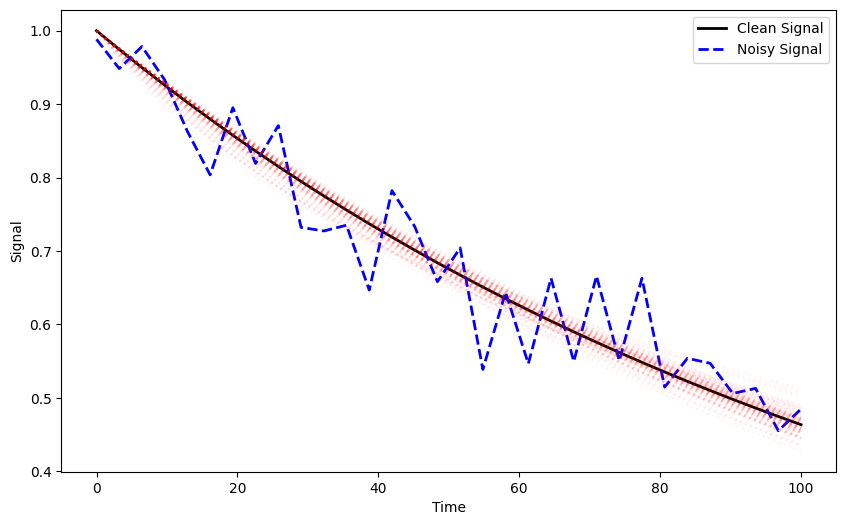

In [8]:
# visualize all of the curves on top of each other
fig = plt.figure(figsize=(10, 6))
plt.plot(t, clean_signal, label='Clean Signal', linewidth=2, color='black')
plt.plot(t, noisy_signal, label='Noisy Signal', linestyle='dashed', linewidth=2, color='blue')
for clean_signal_recovered in clean_signals:
    plt.plot(t, clean_signal_recovered, linestyle='dotted', alpha=0.05, color='red')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Signal')

In [9]:
solutions = np.array(solutions)
true_solution = np.array([c1.item(), lambda1.item(), lambda2.item()])
rel_errors = np.linalg.norm(solutions - true_solution, axis=1) / np.linalg.norm(true_solution)
rel_rmse = np.sqrt(np.mean(rel_errors ** 2))
print(f'Relative RMSE of recovered parameters: {rel_rmse:.4f}')

Relative RMSE of recovered parameters: 1.1065
